# Notebook 09.2: ResNet18 Full Fine-Tune with AdamW

Single-backbone baseline with full fine-tuning from the start, matching the recent training style so results are easy to compare and ensemble later.


---
## Step 1: Imports


In [1]:
import copy
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
from PIL import Image
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

from torchvision.models import ResNet18_Weights, resnet18

print("Imports OK")


Imports OK


/Users/jasonsmith/Desktop/medical-cv-hackathon/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 2: Reproducibility and device


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Device: {device}")


Device: mps


## Step 3: Configuration


In [3]:
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TRAIN_CSV = REPO / "data" / "train_val" / "train_val.csv"
TRAIN_IMG_DIR = REPO / "data" / "train_val" / "images"
TEST_IMG_DIR = REPO / "data" / "test_images"
PRED_DIR = REPO / "outputs" / "predictions"
CKPT_DIR = REPO / "outputs" / "checkpoints"
PRED_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

NUM_WORKERS = 0
VAL_FRAC = 0.2
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

IMG_SIZE = 256
BATCH_SIZE = 8
EPOCHS = 10
LR = 1e-4
WEIGHT_DECAY = 1e-4
DROPOUT = 0.3

print(f"IMG_SIZE     : {IMG_SIZE}")
print(f"BATCH_SIZE   : {BATCH_SIZE}")
print(f"EPOCHS       : {EPOCHS}")
print(f"LR           : {LR}")
print(f"WEIGHT_DECAY : {WEIGHT_DECAY}")
print(f"DROPOUT      : {DROPOUT}")


IMG_SIZE     : 256
BATCH_SIZE   : 8
EPOCHS       : 10
LR           : 0.0001
WEIGHT_DECAY : 0.0001
DROPOUT      : 0.3


## Step 4: Load labels


In [4]:
df = pd.read_csv(TRAIN_CSV)
df = df.rename(columns={
    "Image Index": "image_file",
    "Finding Labels": "finding",
})
df["label"] = (df["finding"] == "Cardiomegaly").astype(int)

print(df[["image_file", "label"]].head())
print(df["label"].value_counts())


       image_file  label
0  IMG_000838.png      1
1  IMG_000239.png      1
2  IMG_000217.png      0
3  IMG_001193.png      0
4  IMG_001097.png      0
label
0    858
1    720
Name: count, dtype: int64


## Step 5: Dataset and transforms


In [5]:
class CardiomegalyDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, return_label=True):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.transform = transform
        self.return_label = return_label

    def __len__(self):
        return len(self.df)

    def _load_image(self, fname):
        img = Image.open(self.img_dir / fname)
        if img.mode != "RGB":
            img = img.convert("RGB")
        return img

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = self._load_image(row["image_file"])
        if self.transform is not None:
            img = self.transform(img)
        if not self.return_label:
            return img, row["image_file"]
        return img, torch.tensor(row["label"], dtype=torch.float32)

def build_transform(img_size, augment=False):
    ops = [T.Resize((img_size, img_size))]
    if augment:
        ops += [
            T.RandomHorizontalFlip(p=0.5),
            T.RandomRotation(degrees=5),
            T.RandomAffine(degrees=0, translate=(0.03, 0.03), scale=(0.95, 1.05)),
            T.ColorJitter(brightness=0.1, contrast=0.1),
        ]
    ops += [
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
    return T.Compose(ops)


## Step 6: Train / validation split and loaders


In [6]:
train_df, val_df = train_test_split(
    df,
    test_size=VAL_FRAC,
    stratify=df["label"],
    random_state=SEED,
)

print(f"Train: {len(train_df)}  (pos rate {train_df['label'].mean():.3f})")
print(f"Val  : {len(val_df)}  (pos rate {val_df['label'].mean():.3f})")

train_tf = build_transform(IMG_SIZE, augment=True)
val_tf = build_transform(IMG_SIZE, augment=False)

train_ds = CardiomegalyDataset(train_df, TRAIN_IMG_DIR, transform=train_tf)
val_ds = CardiomegalyDataset(val_df, TRAIN_IMG_DIR, transform=val_tf)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=False,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False,
)

print(f"Train batches: {len(train_loader)}")
print(f"Val   batches: {len(val_loader)}")


Train: 1262  (pos rate 0.456)
Val  : 316  (pos rate 0.456)
Train batches: 158
Val   batches: 40


## Step 7: Metrics and training helpers


In [7]:
def sens_spec(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    pred = (y_prob >= threshold).astype(int)
    tp = int(((pred == 1) & (y_true == 1)).sum())
    tn = int(((pred == 0) & (y_true == 0)).sum())
    fp = int(((pred == 1) & (y_true == 0)).sum())
    fn = int(((pred == 0) & (y_true == 1)).sum())
    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    return sens, spec

def datathon_score(auroc, sens, spec):
    return 0.5 * auroc + 0.25 * sens + 0.25 * spec

def best_threshold_score(y_true, y_prob):
    auroc = roc_auc_score(y_true, y_prob)
    best_thr, best_score = 0.5, -1.0
    for thr in np.linspace(0.01, 0.99, 199):
        sens, spec = sens_spec(y_true, y_prob, threshold=thr)
        score = datathon_score(auroc, sens, spec)
        if score > best_score:
            best_thr, best_score = thr, score
    return best_thr, best_score

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    ys, ps = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        logits = model(imgs).squeeze(1)
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        ys.extend(labels.numpy().tolist())
        ps.extend(probs.tolist())
    ys = np.array(ys)
    ps = np.array(ps)
    auroc = roc_auc_score(ys, ps)
    sens, spec = sens_spec(ys, ps, threshold=0.5)
    return {"auroc": auroc, "sens": sens, "spec": spec, "y": ys, "p": ps}

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total = 0.0
    pbar = tqdm(loader, leave=False)
    for imgs, labels in pbar:
        imgs = imgs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs).squeeze(1)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total += loss.item()
        pbar.set_description(f"loss {loss.item():.3f}")
    return total / len(loader)

def train(model, train_loader, val_loader, optimizer, scheduler, epochs, device, tag="model", pos_weight_value=None):
    if pos_weight_value is None:
        pos_weight_value = train_df["label"].eq(0).sum() / train_df["label"].eq(1).sum()
    pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    best = {"score": -1.0, "state": None, "epoch": 0}
    history = []
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val = evaluate(model, val_loader, device)
        thr, tuned_score = best_threshold_score(val["y"], val["p"])
        sens_t, spec_t = sens_spec(val["y"], val["p"], threshold=thr)
        dt = time.time() - t0
        history.append({
            "epoch": epoch,
            "loss": tr_loss,
            "auroc": val["auroc"],
            "sens": sens_t,
            "spec": spec_t,
            "thr": thr,
            "score": tuned_score,
        })
        star = ""
        if tuned_score > best["score"]:
            best = {
                "score": tuned_score,
                "auroc": val["auroc"],
                "sens": sens_t,
                "spec": spec_t,
                "thr": thr,
                "state": copy.deepcopy(model.state_dict()),
                "epoch": epoch,
            }
            star = " ★"
            torch.save(model.state_dict(), CKPT_DIR / f"{tag}_best.pt")
        scheduler.step()
        print(
            f"[{tag}] ep {epoch:02d}/{epochs}  loss {tr_loss:.4f}  "
            f"AUROC {val['auroc']:.4f}  sens {sens_t:.3f}  spec {spec_t:.3f}  "
            f"score {tuned_score:.4f}  thr {thr:.3f}  ({dt:.1f}s){star}"
        )
    model.load_state_dict(best["state"])
    return model, pd.DataFrame(history), best


## Step 8: Build full fine-tune model


In [8]:
def build_model(dropout=DROPOUT):
    model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Sequential(nn.Dropout(dropout), nn.Linear(model.fc.in_features, 1))
    return model

model = build_model().to(device)
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model.parameters())
print(f"Trainable: {n_trainable:,} / {n_total:,} ({100*n_trainable/n_total:.2f}%)")


Trainable: 11,177,025 / 11,177,025 (100.00%)


## Step 9: Train


In [9]:
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

model, history_df, best = train(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    epochs=EPOCHS,
    device=device,
    tag="resnet_fullft",
)

print("\nBest checkpoint:")
print(best)


[resnet_fullft] ep 01/10  loss 0.6557  AUROC 0.8702  sens 0.799  spec 0.837  score 0.8441  thr 0.807  (38.1s) ★


[resnet_fullft] ep 02/10  loss 0.5182  AUROC 0.9293  sens 0.917  spec 0.779  score 0.8886  thr 0.668  (33.4s) ★


[resnet_fullft] ep 03/10  loss 0.4812  AUROC 0.9157  sens 0.896  spec 0.791  score 0.8795  thr 0.658  (33.4s)


[resnet_fullft] ep 04/10  loss 0.4294  AUROC 0.9259  sens 0.924  spec 0.785  score 0.8901  thr 0.099  (33.2s) ★


[resnet_fullft] ep 05/10  loss 0.3695  AUROC 0.9437  sens 0.917  spec 0.872  score 0.9190  thr 0.277  (33.1s) ★


[resnet_fullft] ep 06/10  loss 0.3034  AUROC 0.9413  sens 0.854  spec 0.890  score 0.9066  thr 0.639  (33.2s)


[resnet_fullft] ep 07/10  loss 0.2561  AUROC 0.9356  sens 0.854  spec 0.878  score 0.9008  thr 0.713  (33.3s)


[resnet_fullft] ep 08/10  loss 0.2189  AUROC 0.9414  sens 0.882  spec 0.855  score 0.9049  thr 0.381  (33.2s)


[resnet_fullft] ep 09/10  loss 0.2281  AUROC 0.9415  sens 0.861  spec 0.895  score 0.9098  thr 0.634  (33.5s)


[resnet_fullft] ep 10/10  loss 0.1975  AUROC 0.9448  sens 0.854  spec 0.907  score 0.9127  thr 0.579  (35.7s)

Best checkpoint:
{'score': 0.9190285852713178, 'auroc': 0.9436773255813954, 'sens': 0.9166666666666666, 'spec': 0.872093023255814, 'thr': np.float64(0.2772727272727273), 'state': OrderedDict([('conv1.weight', tensor([[[[-1.0841e-02, -5.8652e-03, -1.6300e-03,  ...,  5.7256e-02,
            1.8138e-02, -1.1748e-02],
          [ 1.1162e-02,  1.0525e-02, -1.0911e-01,  ..., -2.7038e-01,
           -1.2799e-01,  4.9440e-03],
          [-7.2175e-03,  5.9757e-02,  2.9614e-01,  ...,  5.2018e-01,
            2.5705e-01,  6.4418e-02],
          ...,
          [-2.7112e-02,  1.7238e-02,  7.3631e-02,  ..., -3.3267e-01,
           -4.2062e-01, -2.5788e-01],
          [ 3.1227e-02,  4.2359e-02,  6.3862e-02,  ...,  4.1376e-01,
            3.9359e-01,  1.6600e-01],
          [-1.2870e-02, -2.5626e-03, -2.3632e-02,  ..., -1.5121e-01,
           -8.2269e-02, -6.0059e-03]],

         [[-1.1780e-0

## Step 10: Plot training history


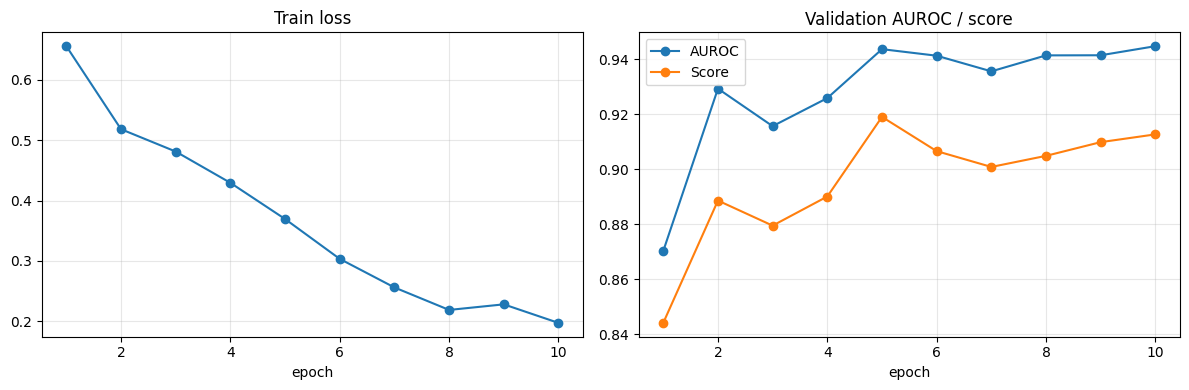

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_df["epoch"], history_df["loss"], marker="o")
axes[0].set_title("Train loss")
axes[0].set_xlabel("epoch")
axes[0].grid(alpha=0.3)

axes[1].plot(history_df["epoch"], history_df["auroc"], marker="o", label="AUROC")
axes[1].plot(history_df["epoch"], history_df["score"], marker="o", label="Score")
axes[1].set_title("Validation AUROC / score")
axes[1].set_xlabel("epoch")
axes[1].grid(alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()


## Step 10.1: Overfitting Check (train vs validation)


     split      thr    score    auroc     sens     spec
train_eval 0.321818 0.971190 0.986430 0.968750 0.943149
       val 0.277273 0.919029 0.943677 0.916667 0.872093

Generalization gap:
  score gap : +0.0522
  AUROC gap : +0.0428
  sens gap  : +0.0521
  spec gap  : +0.0711


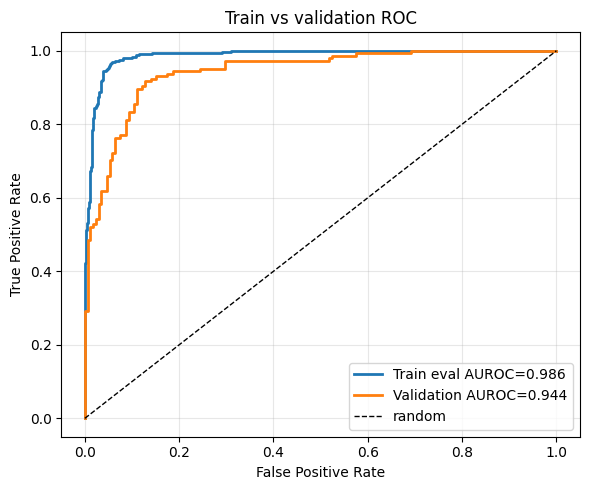

In [11]:
train_eval_ds = CardiomegalyDataset(train_df, TRAIN_IMG_DIR, transform=build_transform(IMG_SIZE, augment=False))
train_eval_loader = DataLoader(
    train_eval_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False,
)

train_eval = evaluate(model, train_eval_loader, device)
train_thr, train_score = best_threshold_score(train_eval["y"], train_eval["p"])
train_sens, train_spec = sens_spec(train_eval["y"], train_eval["p"], threshold=train_thr)

val_eval = evaluate(model, val_loader, device)
val_thr, val_score = best_threshold_score(val_eval["y"], val_eval["p"])
val_sens, val_spec = sens_spec(val_eval["y"], val_eval["p"], threshold=val_thr)

overfit_df = pd.DataFrame([
    {
        "split": "train_eval",
        "thr": train_thr,
        "score": train_score,
        "auroc": train_eval["auroc"],
        "sens": train_sens,
        "spec": train_spec,
    },
    {
        "split": "val",
        "thr": val_thr,
        "score": val_score,
        "auroc": val_eval["auroc"],
        "sens": val_sens,
        "spec": val_spec,
    },
])
print(overfit_df.to_string(index=False))

print("\nGeneralization gap:")
print(f"  score gap : {train_score - val_score:+.4f}")
print(f"  AUROC gap : {train_eval['auroc'] - val_eval['auroc']:+.4f}")
print(f"  sens gap  : {train_sens - val_sens:+.4f}")
print(f"  spec gap  : {train_spec - val_spec:+.4f}")

plt.figure(figsize=(6, 5))
train_fpr, train_tpr, _ = roc_curve(train_eval["y"], train_eval["p"])
val_fpr, val_tpr, _ = roc_curve(val_eval["y"], val_eval["p"])
plt.plot(train_fpr, train_tpr, lw=2, label=f"Train eval AUROC={train_eval['auroc']:.3f}")
plt.plot(val_fpr, val_tpr, lw=2, label=f"Validation AUROC={val_eval['auroc']:.3f}")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Train vs validation ROC")
plt.grid(alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## Step 11: Validation ROC and submission


        model      thr    score    auroc     sens     spec
resnet_fullft 0.277273 0.919029 0.943677 0.916667 0.872093


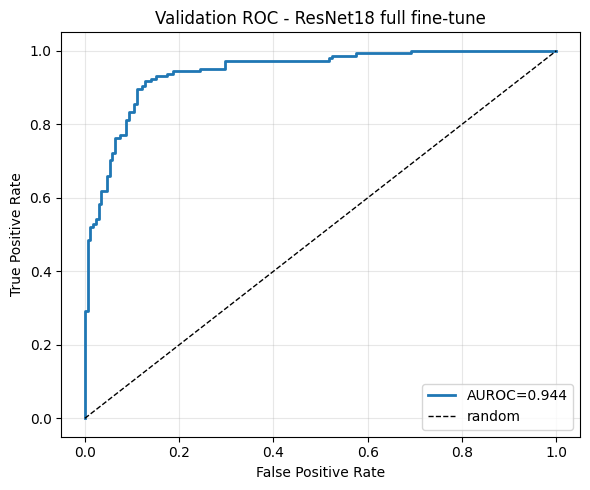

Test images: 176


test inference: 100%|██████████| 22/22 [00:02<00:00,  8.00it/s]


Wrote /Users/jasonsmith/Desktop/medical-cv-hackathon/outputs/predictions/submission_09_2_resnet_fullft_20260421_2305.csv
       image_file      prob  pred
0  IMG_000018.png  0.808953     1
1  IMG_000021.png  0.019772     0
2  IMG_000039.png  0.166658     0
3  IMG_000044.png  0.007940     0
4  IMG_000047.png  0.115476     0

Positive rate in submission: 0.438


In [12]:
val = evaluate(model, val_loader, device)
best_thr, best_score = best_threshold_score(val["y"], val["p"])
best_sens, best_spec = sens_spec(val["y"], val["p"], threshold=best_thr)

summary_df = pd.DataFrame([
    {
        "model": 'resnet_fullft',
        "thr": best_thr,
        "score": best_score,
        "auroc": val["auroc"],
        "sens": best_sens,
        "spec": best_spec,
    }
])
print(summary_df.to_string(index=False))

fpr, tpr, _ = roc_curve(val["y"], val["p"])
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f"AUROC={val['auroc']:.3f}")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title('Validation ROC - ResNet18 full fine-tune')
plt.grid(alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

test_files = sorted(p.name for p in TEST_IMG_DIR.iterdir() if p.suffix.lower() == ".png")
print(f"Test images: {len(test_files)}")

test_df = pd.DataFrame({"image_file": test_files, "label": 0})
test_tf = build_transform(IMG_SIZE, augment=False)
test_ds = CardiomegalyDataset(test_df, TEST_IMG_DIR, transform=test_tf, return_label=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

model.eval()
all_probs, all_names = [], []
with torch.no_grad():
    for imgs, names in tqdm(test_loader, desc="test inference"):
        imgs = imgs.to(device)
        logits = model(imgs).squeeze(1)
        probs = torch.sigmoid(logits)
        all_probs.extend(probs.cpu().numpy().tolist())
        all_names.extend(names)

sub = pd.DataFrame({
    "image_file": all_names,
    "prob": all_probs,
})
sub["pred"] = (sub["prob"] >= best_thr).astype(int)
sub = sub.sort_values("image_file").reset_index(drop=True)

stamp = time.strftime("%Y%m%d_%H%M")
out_path = PRED_DIR / f"submission_09_2_resnet_fullft_{stamp}.csv"
sub.to_csv(out_path, index=False)

print(f"\nWrote {out_path}")
print(sub.head())
print(f"\nPositive rate in submission: {sub['pred'].mean():.3f}")
